In [2]:
# Force the notebook to download the data from Nathaniel Miller's public GitHub repository at launch
!wget https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0198AbuNuwas.txt
!wget https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0211AbuAtahiya.txt

--2026-06-15 18:46:18--  https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0198AbuNuwas.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 618453 (604K) [text/plain]
Saving to: ‘0198AbuNuwas.txt’

0198AbuNuwas.txt    100%[===================>] 603.96K  --.-KB/s    in 0.05s   

2026-06-15 18:46:19 (12.1 MB/s) - ‘0198AbuNuwas.txt’ saved [618453/618453]

--2026-06-15 18:46:19--  https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/0211AbuAtahiya.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting respon

In [3]:
# 1. Install required rendering packages for Arabic right-to-left plotting
!pip install arabic-reshaper python-bidi matplotlib seaborn -q

# 2. Download raw text files directly from GitHub repository
import urllib.request
import os

base_url = "https://raw.githubusercontent.com/nathaniel-a-miller/arabic-poetry-dh/main/data/"
files = ["0198AbuNuwas.txt", "0211AbuAtahiya.txt"]

for f in files:
    try:
        urllib.request.urlretrieve(base_url + f, f)
        print(f"Successfully cached file locally: {f}")
    except Exception as e:
        print(f"Error downloading {f}. Check your repository visibility and URL structure. Error: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 6.9 MB/s eta 0:00:00
Successfully cached file locally: 0198AbuNuwas.txt
Successfully cached file locally: 0211AbuAtahiya.txt


In [73]:
import os
import re
from collections import Counter

# Minimal Arabic stop words (expand as needed)
AR_STOP_WORDS = set([
    "من", "في", "على", "إلى", "عن", "مع", "هذا", "هذه", "التي", "الذي",
    "ان", "أن", "لا", "ما", "يا", "و", "ف", "ب", "ل", "ثم", "أو", "كان", "كانت",
    "البحر", "إذا", "تام", "لم", "ولا", "حتى", "له", "كل", "قد", "إن", "به",
    "لي", "إلا", "بها", "لها", "منه", "غير", "طويل", "فيه", "ذا", "وما",
    "بسيط", "بين", "مجزوء", "وقد", 'قلت', "لو", "فما", "وإن", "لو", "لما",
    "فقلت", "منها", "يوم", "ليس", "كنت", "سريع", "كأن", "بعد", "وافر", "المرء",
    "فيها", "حين", "ال", "أنت","فإن", "مثل", "عليه", "ألا", "ترى", "إذ", "ولم",
    "ومن", "قال", "عند", "كامل",  "وفي", "كما", "علي", "منسرح", "لك", "مني",
    "ذي", "ذاك", "منك", "كأنما", "لنا", "لقد", "وكل", "بما", "كم", "يوما",
    "فقد", "إليه", "رأيت", "فلا", "وأنت", "بي", "شيء", "هو", "خفيف", "وليس",
    "متى", "فإذا", "وإذا", "رجز", "عليك", "الرمل", "نفس", "تر", "إني"
    ])



def parse_and_count(file_path, filter_stops=True):
    text_lines = []
    in_header = True

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find local file: {file_path}")

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            # FIX: Strip spaces to reliably catch the OpenITI header boundary
            if "#META#Header#End#" in line.replace(" ", ""):
                in_header = False
                continue
            if not in_header:
                text_lines.append(line)

    full_text = " ".join(text_lines)

    # Clean up OpenITI layout artifacts (e.g., page numbers, Latin tags)
    full_text = re.sub(r'PageV\d+P\d+\w*', '', full_text)
    full_text = re.sub(r'[A-Za-z0-9]+', '', full_text)

    # Strip tatweel/kashida and harakat (diacritics) for clean matching
    sanitized = re.sub(r'[\u064B-\u0652\u0640]', '', full_text)

    # Tokenize: explicitly capture clusters of Arabic script characters
    words = re.findall(r'[\u0621-\u064A]+', sanitized)

    if filter_stops:
        words = [w for w in words if w not in AR_STOP_WORDS and len(w) > 1]

    return Counter(words)

In [74]:
# Run calculation on the files downloaded in Cell 1
# You can toggle filter_stops to True or False to see the difference
nuwas_counts = parse_and_count("0198AbuNuwas.txt", filter_stops=True)
atah_counts = parse_and_count("0211AbuAtahiya.txt", filter_stops=True)

# Define how many top frequent terms to isolate dynamically
top_n = 10

print(f"--- DYNAMIC TOP {top_n} WORDS: ABU NUWAS ---")
for word, count in nuwas_counts.most_common(top_n):
    print(f"Token: {word} | Count: {count}")

print(f"\n--- DYNAMIC TOP {top_n} WORDS: ABU AL-ATAHIYAH ---")
for word, count in atah_counts.most_common(top_n):
    print(f"Token: {word} | Count: {count}")

--- DYNAMIC TOP 10 WORDS: ABU NUWAS ---
Token: الله | Count: 134
Token: الناس | Count: 102
Token: الدهر | Count: 63
Token: الهوى | Count: 62
Token: الكأس | Count: 60
Token: قلبي | Count: 58
Token: الخمر | Count: 56
Token: الليل | Count: 51
Token: نفسي | Count: 50
Token: الراح | Count: 44

--- DYNAMIC TOP 10 WORDS: ABU AL-ATAHIYAH ---
Token: الدنيا | Count: 98
Token: الله | Count: 83
Token: الناس | Count: 73
Token: الموت | Count: 66
Token: الدهر | Count: 30
Token: لله | Count: 28
Token: دار | Count: 21
Token: عجبا | Count: 19
Token: الفتى | Count: 18
Token: موت | Count: 17


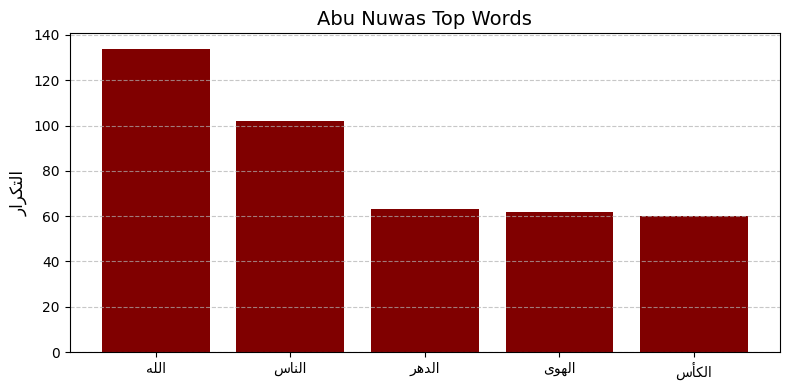

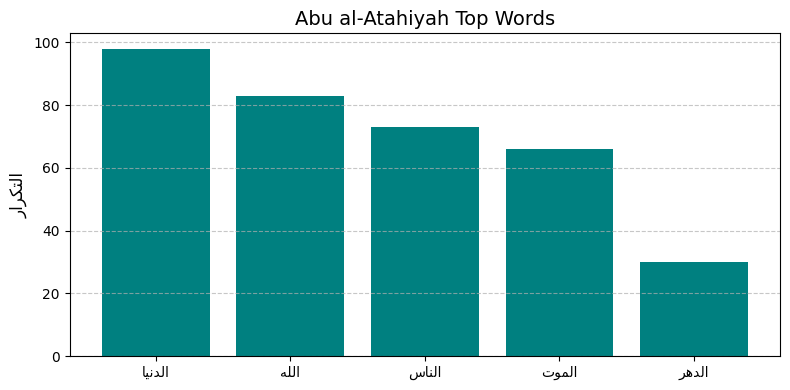

In [81]:
import matplotlib.pyplot as plt
from arabic_reshaper import ArabicReshaper
from bidi.algorithm import get_display

# Configure a reshaper instance that avoids font-breaking single-glyph ligatures
safe_arabic_config = {
    'delete_harakat': True,
    'support_ligatures': False
}
safe_reshaper = ArabicReshaper(configuration=safe_arabic_config)

def plot_top_words(word_counter, title_text="Top Words", color="steelblue"):
    top_5 = word_counter.most_common(5)
    if not top_5:
        print("No data available to plot. Ensure Cell 3 generated counts.")
        return

    words, counts = zip(*top_5)

    # Process the labels using our ligature-safe config
    reshaped_labels = [get_display(safe_reshaper.reshape(w)) for w in words]

    # Generate the bar chart
    plt.figure(figsize=(8, 4))
    plt.bar(reshaped_labels, counts, color=color)

    # Safely shape the chart typography
    plt.title(get_display(safe_reshaper.reshape(title_text)), fontsize=14)
    plt.ylabel(get_display(safe_reshaper.reshape("التكرار")), fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- THE EXECUTION CALLS ---
# These must be un-commented to actually trigger the visualization plots
plot_top_words(nuwas_counts, title_text="Abu Nuwas Top Words", color="maroon")
plot_top_words(atah_counts, title_text="Abu al-Atahiyah Top Words", color="teal")